In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import re
import warnings 
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import  (accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.layers import(Embedding,SimpleRNN,LSTM,GRU,Bidirectional,Dense,Dropout,SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau,ModelCheckpoint)
import  pickle


## IMPORT DATASET 

In [2]:
df1=pd.read_json("Sarcasm_Headlines_Dataset_v2.json",lines=True)

In [3]:
df1.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [4]:
df1.duplicated().sum()

np.int64(2)

In [5]:
df1["headline"].duplicated().sum()

np.int64(116)

In [6]:
df1.drop_duplicates(subset="headline",inplace=True)

In [7]:
df1.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

## TEXT CLEANING MINIMAL (  FOR DEEP LEARNING )

In [8]:
def clean_text(text):
    text= str(text).lower()

    #remove URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
df1["clean_text"]=df1["headline"].apply(clean_text)

In [10]:
df1[["headline","clean_text"]].head(10)

,headline,clean_text
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientists unveil doomsday clo...
1,dem rep. totally nails why congress is falling...,dem rep. totally nails why congress is falling...
2,eat your veggies: 9 deliciously different recipes,eat your veggies: 9 deliciously different recipes
3,inclement weather prevents liar from getting t...,inclement weather prevents liar from getting t...
4,mother comes pretty close to using word 'strea...,mother comes pretty close to using word 'strea...
5,my white inheritance,my white inheritance
6,5 ways to file your taxes with less stress,5 ways to file your taxes with less stress
7,richard branson's global-warming donation near...,richard branson's global-warming donation near...
8,shadow government getting too large to meet in...,shadow government getting too large to meet in...
9,lots of parents know this scenario,lots of parents know this scenario


## DEFINE X AND Y

In [11]:
X=df1["clean_text"]
y=df1["is_sarcastic"]

In [12]:
print("X_shape",X.shape)
print("y_shape:",y.shape)

X_shape (28503,)
y_shape: (28503,)


In [13]:
## TRAIN TEST SPLIT 

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [15]:
print("Training Samples:",len(X_train))
print("Testing Samples",len(X_test))

Training Samples: 22802
Testing Samples 5701


In [16]:
print(y_test.value_counts())

is_sarcastic
0    2990
1    2711
Name: count, dtype: int64


## TOKENIZATION

In [63]:
MAX_WORDS=25000
OOV_TOKEN="<OOV>"

In [64]:
tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token=OOV_TOKEN)

In [65]:
tokenizer.fit_on_texts(X_train)

In [66]:
len(tokenizer.word_index)

27642

In [67]:
list(tokenizer.word_index.items())[-50:]

[("92'", 27593),
 ('rodney', 27594),
 ('bungles', 27595),
 ('depends', 27596),
 ('1996', 27597),
 ('reintegration', 27598),
 ('mumolo', 27599),
 ("'bridesmaids'", 27600),
 ("'shithole'", 27601),
 ('tarot', 27602),
 ('pliers', 27603),
 ("present's", 27604),
 ("rogers'", 27605),
 ('gerrymandered', 27606),
 ('jubilee', 27607),
 ('strata', 27608),
 ('merchandise', 27609),
 ("'hold", 27610),
 ('swinging', 27611),
 ('258', 27612),
 ('159', 27613),
 ('mirena', 27614),
 ('intrauterine', 27615),
 ('shredder', 27616),
 ("'suppressed", 27617),
 ("naked'", 27618),
 ('weirder', 27619),
 ('col', 27620),
 ('samsonite', 27621),
 ('lint', 27622),
 ('cardigan', 27623),
 ('admin', 27624),
 ('popped', 27625),
 ('phat', 27626),
 ('jncos', 27627),
 ('riley', 27628),
 ('imagery', 27629),
 ('stitched', 27630),
 ("wino's", 27631),
 ('bronco', 27632),
 ('forgetful', 27633),
 ('respecting', 27634),
 ('thinner', 27635),
 ('401k', 27636),
 ("rex's", 27637),
 ('rotund', 27638),
 ('replaceable', 27639),
 ("dream'", 

In [68]:
X_train.apply(type).value_counts()

clean_text
<class 'str'>    22802
Name: count, dtype: int64

## Convert Text to Sequence

In [69]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [70]:
print([X_train.iloc[0],X_train_seq[0]])

["'gobbler games' is the brutal hunger games parody you need to see", [14011, 5450, 11, 4, 4223, 2599, 1486, 2600, 20, 167, 2, 178]]


In [71]:
# analyze sequence length before max_len

In [72]:
seq_analyze=[len(sequence) for sequence in X_train_seq]
max(seq_analyze)

152

In [73]:
min(seq_analyze)

2

In [74]:
pd.Series(seq_analyze).describe(percentiles=[0.90,0.95,0.99])

count    22802.000000
mean        10.269275
std          3.445533
min          2.000000
50%         10.000000
90%         14.000000
95%         16.000000
99%         19.000000
max        152.000000
dtype: float64

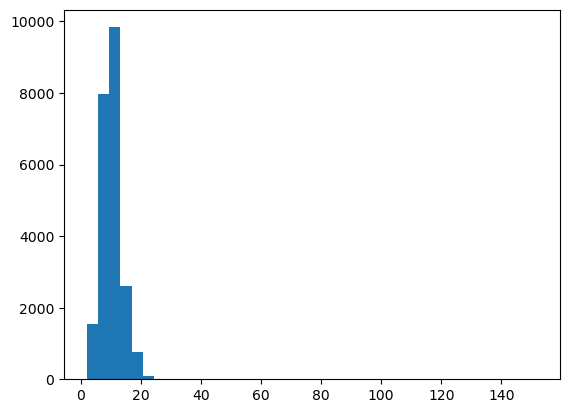

In [75]:
plt.hist( seq_analyze,bins=40)
plt.show()

In [76]:
MAX_LEN= int(np.percentile(seq_analyze,95))
MAX_LEN

16

In [77]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# PADDING
X_train_pad=pad_sequences(X_train_seq,maxlen=MAX_LEN,padding="post",truncating="post")
X_test_pad=pad_sequences(X_test_seq,maxlen=MAX_LEN,padding="post",truncating="post")

In [78]:
# check shape after padding 
print("Train_shape",X_train_pad.shape)
print("Test Shape",X_test_pad.shape)

Train_shape (22802, 16)
Test Shape (5701, 16)


## Define EVALUATION FUNCTION

In [90]:
results1=[]

def evaluation_model(model,model_name,x_test,x_train,y_test,y_train,thersold=0.5):
    # predict probablities
    y_prob_test=model.predict(x_test,verbose=0).ravel()
    y_prob_train=model.predict(x_train,verbose=0).ravel()
    

    #convert probablities into labels
    y_pred_test=(y_prob_test>=thersold).astype(int)
    y_pred_train=(y_prob_train>=thersold).astype(int)

    #claculate metrics
    accuracy_test=accuracy_score(y_test,y_pred_test)
    accuracy_train=accuracy_score(y_train,y_pred_train)

    #recall
    recall=recall_score(y_test,y_pred_test,zero_division=0)

    print( f"MODEL :{model_name}")
    print(f"TEST_ACCURACY:{accuracy_test:.4f}")
    print(f"TRAIN_ACCURACY:{accuracy_train:.4f}")
    print(f"RECALL :{recall:.4f}")

    print("\nClassification_Report\n")
    print(classification_report(y_test,y_pred_test,digits=4,zero_division=0))

    # confusion matrix display 
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test,cmap="Blues")
    plt.title(f"Confusion Matrix :{model_name}")
    plt.show()

    return { "Model":model_name,"Train_accuracy":accuracy_train,"Test_Accuracy":accuracy_test,"Recall":recall}


In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding,SpatialDropout1D,SimpleRNN,Dense,Dropout)

## MODELLING

#### 1.  SIMPLE RNN

In [81]:
rnn_model= Sequential()

#EMBEDDING
rnn_model.add(Embedding(input_dim= MAX_WORDS,output_dim=128,mask_zero=True))

#Spatial Dropout
rnn_model.add(SpatialDropout1D(0.2))

#SimpleRNN
rnn_model.add(SimpleRNN(units=64,dropout=0.2,recurrent_dropout=0.2))

#Dense Layer
rnn_model.add(Dense(units=64,activation="relu"))

#DROPOUT
rnn_model.add(Dropout(0.2))

#OUTPUT LAYER 
rnn_model.add(Dense(units=1,activation="sigmoid"))

In [82]:
rnn_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [83]:
rnn_model.build(input_shape=(None,MAX_LEN))
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 16, 128)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 16, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,216,577 (12.27 MB)

 Trainable params: 3,216,577 (12.27 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
#model train 
rnn_history=rnn_model.fit(X_train_pad,y_train,validation_split=0.2,epochs=15,batch_size=64,verbose=1)

Epoch 1/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.7627 - loss: 0.4909 - val_accuracy: 0.8402 - val_loss: 0.3624
Epoch 2/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9014 - loss: 0.2587 - val_accuracy: 0.8364 - val_loss: 0.3691
Epoch 3/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9498 - loss: 0.1461 - val_accuracy: 0.8279 - val_loss: 0.4553
Epoch 4/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9760 - loss: 0.0761 - val_accuracy: 0.8235 - val_loss: 0.5498
Epoch 5/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.9838 - loss: 0.0482 - val_accuracy: 0.8228 - val_loss: 0.7000
Epoch 6/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9888 - loss: 0.0344 - val_accuracy: 0.8220 - val_loss: 0.6756
Epoch 7/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9907 - loss: 0.0276 - val_accuracy: 0.8174 - val_loss: 0.8059
Epoch 8/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9931 - loss: 0.0210 - 

MODEL :Simple-RNN
TEST_ACCURACY:0.8299
TRAIN_ACCURACY:0.9627
RECALL :0.8167

Classification_Report

              precision    recall  f1-score   support

           0     0.8351    0.8418    0.8384      2990
           1     0.8240    0.8167    0.8203      2711

    accuracy                         0.8299      5701
   macro avg     0.8295    0.8292    0.8294      5701
weighted avg     0.8298    0.8299    0.8298      5701



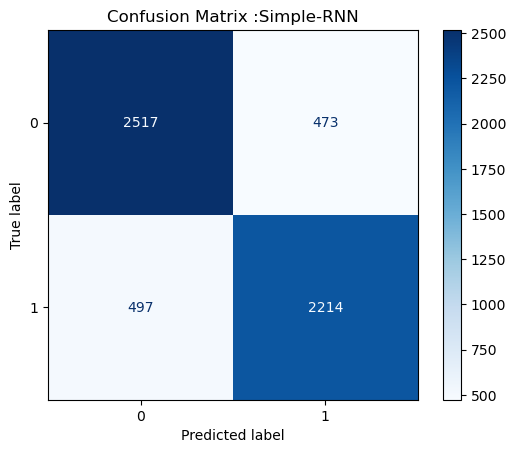

In [91]:
rnn_results=evaluation_model(rnn_model,"Simple-RNN",X_test_pad,X_train_pad,y_test,y_train)

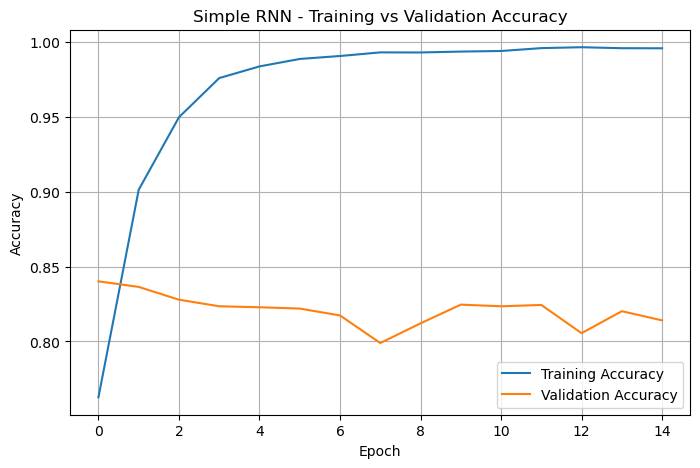

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["accuracy"],label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Simple RNN - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

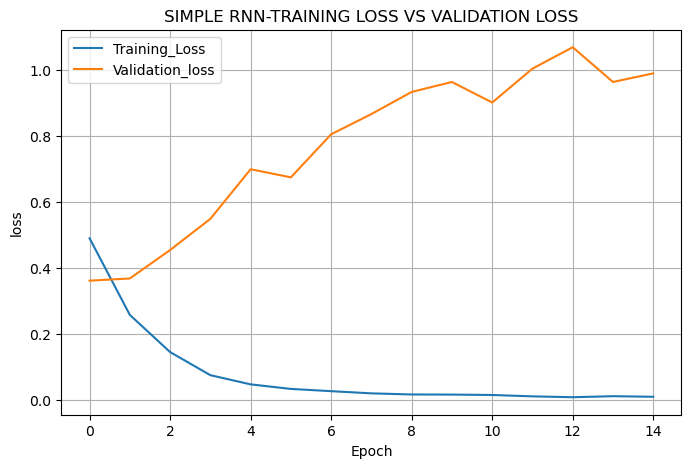

In [93]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH 

plt.figure(figsize=(8,5))

plt.plot(rnn_history.history["loss"],label="Training_Loss")
plt.plot(rnn_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("SIMPLE RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()
          

In [95]:
print(tokenizer.num_words)

25000
